In [ ]:
#Выводы:
#Для выбранных данных по выживаемости на титанке и их зависимости от пола и класса билета из рассмотренных моделей наиболее точно отрабатывает
#логистическая регрессия, оценка качества по критериям accuracy = 0,783, f1_score = 0,718. Не идеальная модель, но лучше других

In [153]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.metrics import f1_score, fbeta_score, r2_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#чтение файла с данными

In [9]:
data = pd.read_csv('train.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#подготовка данных - разбиение на тренировочные и проверочные
#критерий - выживаемость, 1 - пассажир выжил, 0 - не выжил
#смотрю зависимость выживаемости от пола и класса билета

In [105]:
y = data['Survived']
data['Sex'] = pd.factorize(data['Sex'])[0]
X = data[['Sex', 'Pclass']].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2023, test_size=0.15, stratify = y)

In [ ]:
#варианты результатов - нули и единицы, примерно 2 к 1,25 (8 к 5)

<Axes: title={'center': 'Target density'}, ylabel='Density'>

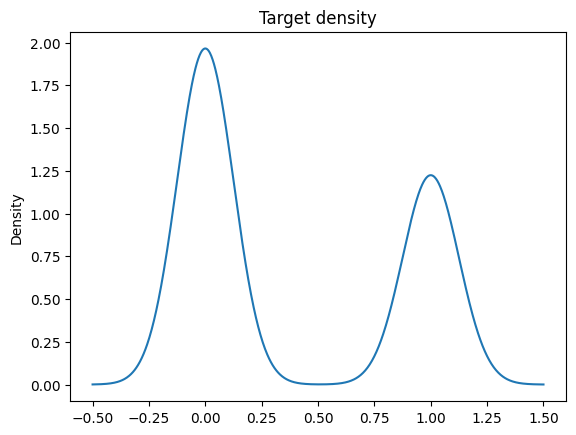

In [106]:
y.plot(kind='kde', title='Target density')

In [107]:
#Dummy классификатор

In [108]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [109]:
# dummy регрессия

In [110]:
dummy = DummyRegressor(strategy='median')
dummy.fit(X_train, y_train)
y_preds_dummy = dummy.predict(X_test)

In [111]:
#логистическая регрессия

In [112]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [113]:
#линейная регрессия

In [114]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds_lr = lr.predict(X_test)

In [115]:
#критерий - точность

In [116]:
y_pred_dummy = dummy_clf.predict(X_test)
accuracy_score(y_test, y_pred_dummy)

0.6194029850746269

In [117]:
y_pred_log_reg = log_reg.predict(X_test)
accuracy_score(y_test, y_pred_log_reg)

0.7835820895522388

In [118]:
#по критерию "accuracy" получены значения:
#Dummy - ~0.619, LogReg ~0.78. Логистическая регрессия ненамного, но лучше, чем Dummy

In [119]:
#критерий - precision

In [120]:
#матрица ошибок для dummy
confusion_matrix(y_test, y_pred_dummy)

array([[83,  0],
       [51,  0]], dtype=int64)

In [ ]:
#для dummy precision даже определяться не хочет, не угадывает совсем

In [121]:
precision_score(y_test, y_pred_dummy)

C:\Users\Alex\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.0

In [122]:
# критерий - recall

In [123]:
recall_score(y_test, y_pred_dummy)

0.0

In [124]:
#матрица ошибок для логистической регрессии
confusion_matrix(y_test, y_pred_log_reg)

array([[68, 15],
       [14, 37]], dtype=int64)

In [ ]:
#по матрице видно, что у модели очень много ошибок

In [125]:
precision_score(y_test, y_pred_log_reg)

0.7115384615384616

In [126]:
recall_score(y_test, y_pred_log_reg)

0.7254901960784313

In [127]:
#по критериям precision и recall получены значения:
# для dummy оба равны нулю (никаких попаданий), для логистической регрессии ~0,711 и ~0,725 соответственно (не очень хороши,
# но потом стало понятно, что лучшее, что было проверено). значение близко к accuracy

In [128]:
# критерий F-мера

In [129]:
f1_score(y_test, y_pred_dummy)

0.0

In [130]:
f1_score(y_test,y_pred_log_reg)

0.7184466019417476

In [131]:
# f-мера для dummy стабильно равна 0, для логистической регрессии ~0,718 (среднее между пресижн и реколом, как и положено)

In [132]:
fbeta_score(y_test, y_pred_dummy, beta = 2)

0.0

In [133]:
fbeta_score(y_test, y_pred_log_reg, beta = 2)

0.72265625

In [134]:
# при beta = 2 (сдвиг в сторону рекола) значение не сильно отличается от предыдущих, но чуть выше стало.

In [135]:
#критерий MSE

In [136]:
mean_squared_error(y_test, y_preds_dummy)

0.3805970149253731

In [137]:
mean_squared_error(y_test, y_preds_lr)

0.14702285196890305

In [138]:
# для dummy - 0.3806, для linregr - 0,1470. квадрат ошибки для линейной регрессии меньше, чем для dummy

In [139]:
# критерий RMSE

In [140]:
root_mean_squared_error(y_test, y_preds_dummy)

0.6169254532967279

In [141]:
root_mean_squared_error(y_test, y_preds_lr)

0.38343559037849245

In [142]:
#для dummy - 0.617, для linregr - 0.383 - в два раза меньше , чем для dummy

In [143]:
def plot_model_results(actual, predicted, title):
    results = pd.DataFrame({'True': actual, 'Prediction': predicted})
    sns.lmplot(x='True', y='Prediction', data=results, fit_reg=False)
    d_line= np.arange(results.min().min(), results.max().max())
    plt.plot(d_line, d_line, color='red', linestyle='--')
    plt.title= title
    plt.grid()
    plt.show()

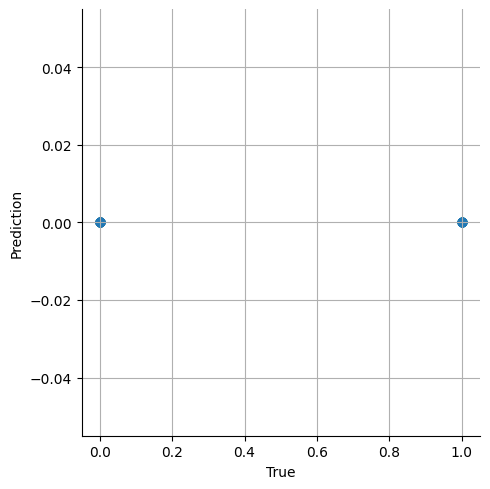

In [144]:
plot_model_results(y_test, y_preds_dummy, title='Dummy')
#не строится красная линия, все значение модели - нули, что логично, тех, кто не выжил - больше

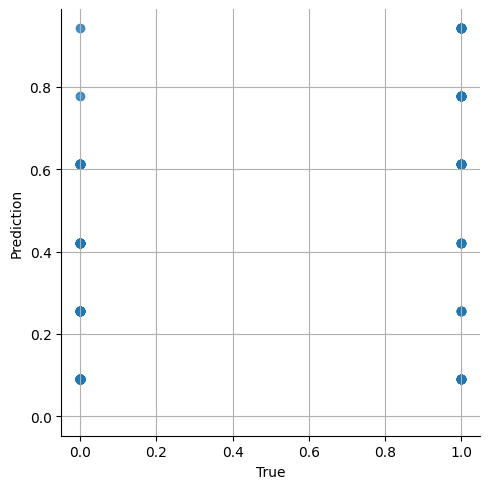

In [89]:
plot_model_results(y_test, y_preds_lr, title='Linear Regression')
#опять не строится красная линия, предсказания странно распределены

In [ ]:
# критерий - MAE

In [145]:
mean_absolute_error(y_test, y_preds_dummy)

0.3805970149253731

In [146]:
mean_absolute_error(y_test, y_preds_lr)

0.3109182023697093

In [ ]:
#для dummy 0.381, для linregr - 0.311. не очень большая разница, но у линрегр все-таки меньше значение


In [ ]:
#критерий MAPE

In [147]:
mean_absolute_percentage_error(y_test, y_preds_dummy)

0.3805970149253731

In [148]:
mean_absolute_percentage_error(y_test, y_preds_lr)

755089344090402.8

In [ ]:
#для linregr ошибка получилась страшная, не очень понятно, с чем связано

In [ ]:
# критерий r2

In [149]:
r2_score(y_test, y_preds_dummy)

-0.6144578313253011

In [150]:
r2_score(y_test,y_preds_lr)

0.3763424687092788

In [ ]:
#по критерию r2 для dummy ошибка отрицательная, для linregr - ~0,376, положительная, ~треть от максимальной (1), плохая модель для данного набора данных


In [ ]:
#использование кросс-валидации

In [154]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
log_reg = LogisticRegression()
cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring = 'f1')

array([0.72072072, 0.7962963 , 0.71428571, 0.58928571, 0.72727273])

In [ ]:
#при разбиении на 5 фолдов видно, что правильных ответов во всех фолдах не много (далеко до единицы), поэтому использовать ее в данном случае нет смысла